In [1]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def augment_images(input_folder, output_folder, target_size=(224, 224), augment_count=8):

    # Create the output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    # Data augmentation setup
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Loop through all images in the input folder
    for file_name in os.listdir(input_folder):
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            input_path = os.path.join(input_folder, file_name)

            # Load and preprocess image
            image = cv2.imread(input_path)
            if image is None:
                print(f"Failed to load {input_path}")
                continue

            # Resize image
            resized_image = cv2.resize(image, target_size)

            # Normalize pixel values
            normalized_image = resized_image / 255.0

            # Expand dimensions to match batch format for ImageDataGenerator
            normalized_image_expanded = np.expand_dims(normalized_image, axis=0)

            # Generate augmented images
            augmented_iterator = datagen.flow(
                normalized_image_expanded,
                batch_size=1,
                save_to_dir=output_folder,
                save_prefix=file_name.split('.')[0],
                save_format='jpg'
            )

            # Save the specified number of augmented images
            for _ in range(augment_count):
                next(augmented_iterator)

# Input and output folder paths
input_folder = "F:/Pavements/cracked"
output_folder = "F:/Pavements/augmented"

# Augment images
# augment_images(input_folder, output_folder, target_size=(224, 224), augment_count=8)


In [2]:
###ROBUST ATTENTION-DRIVEN DENSENET FRAMEWORK FOR ACCURATE STRUCTURAL HEALTH AND CRACK DETECTION
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
###Adaptive Image Enhancement (AIE) 
def create_output_folders(base_input, base_output):
    """Create a mirrored folder structure in the output directory."""
    for root, dirs, _ in os.walk(base_input):
        for dir_name in dirs:
            input_subfolder = os.path.join(root, dir_name)
            output_subfolder = input_subfolder.replace(base_input, base_output)
            os.makedirs(output_subfolder, exist_ok=True)

def adaptive_image_enhancement(input_folder, output_folder, target_size=(224, 224)):
    """Apply Adaptive Image Enhancement (AIE) to images in the input folder."""
    # Create output folders
    create_output_folders(input_folder, output_folder)

    # Data augmentation setup
    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    for root, _, files in os.walk(input_folder):
        for file_name in files:
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                # Input and output paths
                input_path = os.path.join(root, file_name)
                output_path = input_path.replace(input_folder, output_folder)

                # Load image
                image = cv2.imread(input_path)
                if image is None:
                    print(f"Failed to load {input_path}")
                    continue

                # Phase 1: Resize image
                resized_image = cv2.resize(image, target_size)

                # Phase 2: Normalize pixel values
                normalized_image = resized_image / 255.0

                # Phase 3: Apply data augmentation (generate one augmented image)
                normalized_image_expanded = np.expand_dims(normalized_image, axis=0)  # Add batch dimension
                augmented_iterator = datagen.flow(normalized_image_expanded, batch_size=1)
                augmented_image = next(augmented_iterator)[0]  # Extract the augmented image

                # Phase 4: Apply bilateral filter
                augmented_image_uint8 = (augmented_image * 255).astype(np.uint8)  # Convert back to uint8
                bilateral_filtered_image = cv2.bilateralFilter(augmented_image_uint8, d=9, sigmaColor=75, sigmaSpace=75)

                # Save processed image
                cv2.imwrite(output_path, bilateral_filtered_image)

# Define input and output folders
input_folder = "F:/Pavements/augmented"
output_folder = "F:/Pavements/pavements_preprocessed"

# Apply AIE
adaptive_image_enhancement(input_folder, output_folder)

In [3]:
import os
import cv2
import numpy as np
from skimage.feature import local_binary_pattern
from tensorflow.keras.preprocessing.image import ImageDataGenerator
###Integrated Feature Detection System (IFDS)
def integrated_feature_detection_system(input_folder, output_folder):
    """Apply Integrated Feature Detection System (IFDS) to images in the input folder."""
    # Create output folders
    create_output_folders(input_folder, output_folder)

    for root, _, files in os.walk(input_folder):
        for file_name in files:
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                # Input and output paths
                input_path = os.path.join(root, file_name)
                output_path = input_path.replace(input_folder, output_folder)

                # Load image
                image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
                if image is None:
                    print(f"Failed to load {input_path}")
                    continue

                # Apply Canny Edge Detection
                edges = cv2.Canny(image, threshold1=50, threshold2=150)

                # Apply Local Binary Patterns (LBP)
                lbp = local_binary_pattern(image, P=8, R=1, method='uniform')

                # Combine edges and LBP for visualization (optional, normalize LBP for consistency)
                lbp_normalized = cv2.normalize(lbp, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX).astype(np.uint8)
                combined = cv2.addWeighted(edges, 0.5, lbp_normalized, 0.5, 0)

                # Save processed image
                cv2.imwrite(output_path, combined)

# Define input and output folders
input_folder = "F:/Pavements/pavements_preprocessed"
output_folder = "F:/Pavements/pavements_canny"

# Apply IFDS
integrated_feature_detection_system(input_folder, output_folder)


In [8]:
import os
import cv2
import numpy as np
from PIL import Image  # Import Image module from PIL

data = []
labels = []

height = 64
width = 64
channels = 3


path1 ="F:/Pavements/pavements_preprocessed/Cracked/"

path2 = "F:/Pavements/pavements_preprocessed/Non-cracked/"

path = [path1, path2]

for i, p in enumerate(path):
    Class = os.listdir(p)
    for a in Class:
        if a.endswith('.jpg') or a.endswith('.bmp'):  # Check if file is an image
            labels.append(i)
            try:
                image = cv2.imread(os.path.join(p, a))
                if image is not None:
                    image_from_array = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                    size_image = image_from_array.resize((height, width))
                    data.append(np.array(size_image))
                else:
                    print(f"Error: Unable to read image at {os.path.join(p, a)}")
            except Exception as e:
                print(f"Error: {e}")

# Convert data and labels to numpy arrays
labels = np.array(labels)
data = np.array(data)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# Randomize the order of the input images
s = np.arange(data.shape[0])
np.random.seed(43)
np.random.shuffle(s)
data = data[s]
labels = labels[s]


Data shape: (42581, 64, 64, 3)
Labels shape: (42581,)


In [9]:
merged_data = data

# Merge labels and label1
merged_labels =labels

# Shuffle merged data and labels
shuffle_indices = np.arange(merged_data.shape[0])
np.random.shuffle(shuffle_indices)
merged_data_shuffled = merged_data[shuffle_indices]
merged_labels_shuffled = merged_labels[shuffle_indices]

In [10]:
#####Enhanced DenseNet
import os
import cv2
import numpy as np
from PIL import Image  # Import Image module from PIL
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC
from sklearn.metrics import f1_score, accuracy_score
from keras.models import Sequential

def cbam_block(input_tensor, reduction_ratio=8):
    """Convolutional Block Attention Module (CBAM)."""
    channel = input_tensor.shape[-1]

    # Channel Attention
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=[1, 2], keepdims=True))(input_tensor)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=[1, 2], keepdims=True))(input_tensor)
    shared_mlp = Sequential([
        layers.Dense(channel // reduction_ratio, activation='relu'),
        layers.Dense(channel, activation='sigmoid')
    ])
    channel_attention = layers.Add()([
        shared_mlp(avg_pool),
        shared_mlp(max_pool)
    ])
    channel_refined = layers.Multiply()([input_tensor, channel_attention])

    # Spatial Attention
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)
    spatial_attention = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(spatial_attention)
    spatial_refined = layers.Multiply()([channel_refined, spatial_attention])

    return spatial_refined



# Build Enhanced DenseNet Model
def build_enhanced_densenet(input_shape=(64, 64, 3), num_classes=1):
    """Builds DenseNet121 with CBAM for binary classification."""
    base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = cbam_block(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model

# Compile Model
model = build_enhanced_densenet()
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)



In [12]:
# merged_data_shuffled1 = np.concatenate((merged_data_shuffled, merged_data_shuffled), axis=0)
# merged_labels_shuffled1 = np.concatenate((merged_labels_shuffled, merged_labels_shuffled), axis=0)
train_split = int(0.8 * len(merged_data_shuffled))
test_split = int(0.9 * len(merged_data_shuffled))
import numpy as np

train_data = merged_data_shuffled[:train_split]
train_labels = merged_labels_shuffled[:train_split]
test_data = merged_data_shuffled[test_split:]
test_labels = merged_labels_shuffled[test_split:]

# Normalize data
train_data = train_data / 255.0
test_data = test_data / 255.0

# Build Enhanced DenseNet Model
model = build_enhanced_densenet()
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    train_data, train_labels,
    validation_data=(test_data, test_labels),  # Set validation data to the test data
    epochs=25,
    batch_size=32
)



Epoch 1/25
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 99s 85ms/step - accuracy: 0.9072 - loss: 0.2305 - val_accuracy: 0.9500 - val_loss: 0.1290
Epoch 2/25
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 86s 81ms/step - accuracy: 0.9557 - loss: 0.1182 - val_accuracy: 0.9552 - val_loss: 0.1234
Epoch 3/25
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 83s 78ms/step - accuracy: 0.9637 - loss: 0.0978 - val_accuracy: 0.9584 - val_loss: 0.1137
Epoch 4/25
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 81s 76ms/step - accuracy: 0.9714 - loss: 0.0746 - val_accuracy: 0.9591 - val_loss: 0.1098
Epoch 5/25
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 80s 75ms/step - accuracy: 0.9756 - loss: 0.0636 - val_accuracy: 0.9620 - val_loss: 0.0986
Epoch 6/25
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 80s 75ms/step - accuracy: 0.9797 - loss: 0.0551 - val_accuracy: 0.9624 - val_loss: 0.1298
Epoch 7/25
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 80s 75ms/step - accuracy: 0.9837 - loss: 0.0433 - val_accuracy: 0.9561 - val_loss: 0.1394
Epoch 8/25
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 80s 75ms/step - accuracy: 0.9849 -

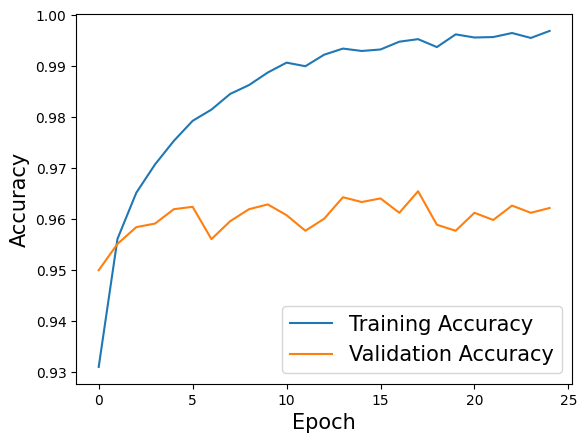

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch',fontsize=15)
plt.ylabel('Accuracy',fontsize=15)
plt.legend(fontsize=15)
plt.show()

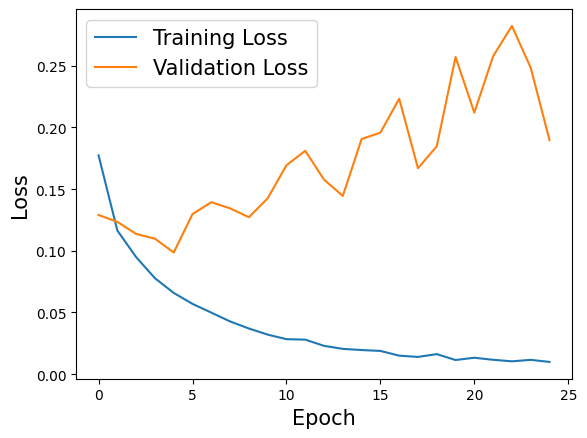

In [14]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch',fontsize=15)
plt.ylabel('Loss',fontsize=15)
plt.legend(fontsize=15)
plt.show()

In [15]:
# Evaluate Model
predictions = model.predict(test_data)
confidence_threshold = 0.5
binary_predictions = (predictions > confidence_threshold).astype(int)

accuracy = accuracy_score(test_labels, binary_predictions)
precision = Precision()(test_labels, binary_predictions).numpy()
recall = Recall()(test_labels, binary_predictions).numpy()
f1 = f1_score(test_labels, binary_predictions)

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step
Accuracy: 0.9622, Precision: 0.9607, Recall: 0.9663, F1-Score: 0.9635


In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, binary_predictions))



Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2061
           1       0.96      0.97      0.96      2198

    accuracy                           0.96      4259
   macro avg       0.96      0.96      0.96      4259
weighted avg       0.96      0.96      0.96      4259



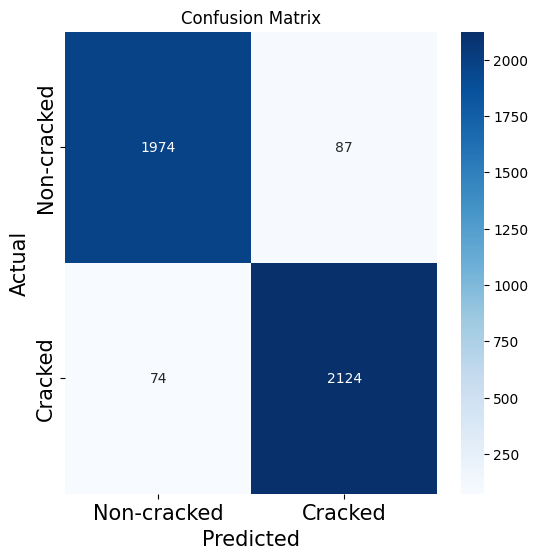

In [17]:
cm = confusion_matrix(test_labels, binary_predictions)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-cracked', 'Cracked'], yticklabels=['Non-cracked', 'Cracked'])
plt.xlabel('Predicted',fontsize=15)
plt.ylabel('Actual',fontsize=15)
plt.title('Confusion Matrix')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()


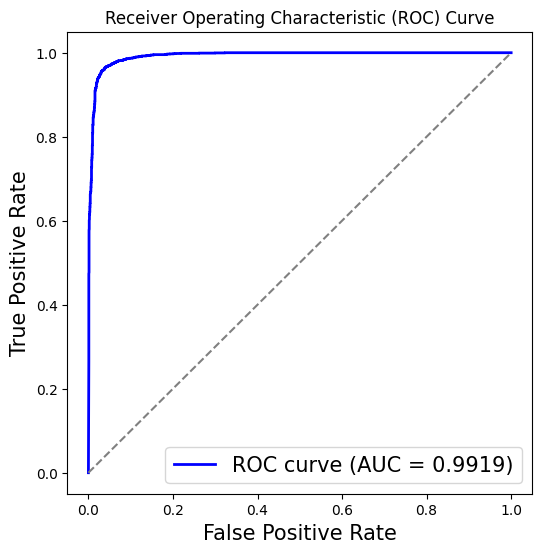

In [18]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(test_labels, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate',fontsize=15)
plt.ylabel('True Positive Rate',fontsize=15)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right',fontsize=15)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


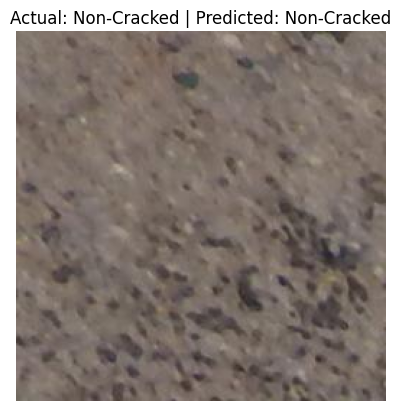

In [19]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def preprocess_image(image_path, target_size=(64, 64)):
    """Preprocess the image to fit the model input."""
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Unable to read image at {image_path}")
        return None, None

    # Convert to RGB (if necessary)
    image_from_array = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    
    # Resize the image
    resized_image = image_from_array.resize(target_size)
    
    # Convert to numpy array and normalize
    image_array = np.array(resized_image) / 255.0  # Normalize to [0, 1]
    
    # Add batch dimension (model expects 4D input)
    image_array = np.expand_dims(image_array, axis=0)

    return image_array, image_from_array  # Return both the processed array and the original image

def predict_single_image(model, image_path, actual_label):
    """Make a prediction for a single image."""
    image_array, original_image = preprocess_image(image_path)
    if image_array is None:
        return None, None
    
    # Make prediction
    prediction = model.predict(image_array)
    
    # Convert the predicted value to a label
    predicted_label = "Non-Cracked" if prediction[0][0] > 0.5 else "Cracked"
    
    # Return the predicted label, actual label, and the original image
    return predicted_label, actual_label, original_image

# Path to the input image
image_path = "F:/Pavements/augmented/Non-cracked/001-3.jpg"  # Replace with the path to your image
actual_label = "Non-Cracked"  # Specify the actual label for the image

# Get the prediction and original image
predicted_label, actual_label, original_image = predict_single_image(model, image_path, actual_label)

if predicted_label is not None:
    # Display the image with the actual and predicted labels
    plt.imshow(original_image)
    plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}")
    plt.axis('off')  # Turn off axis
    plt.show()
else:
    print("Could not process the image for prediction.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


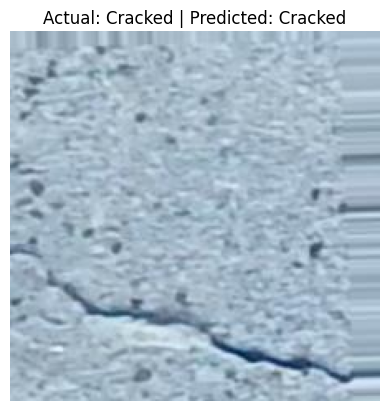

In [22]:
# Path to the input image
image_path = "F:/Pavements/augmented/Cracked/002-125_0_8806.jpg"  # Replace with the path to your image
actual_label = "Cracked"  # Specify the actual label for the image

# Get the prediction and original image
predicted_label, actual_label, original_image = predict_single_image(model, image_path, actual_label)

if predicted_label is not None:
    # Display the image with the actual and predicted labels
    plt.imshow(original_image)
    plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}")
    plt.axis('off')  # Turn off axis
    plt.show()
else:
    print("Could not process the image for prediction.")
